# 对应 tf.keras 的 01～02 章节

In [84]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
"""
    这是Jupyter Notebook/JupyterLab的魔法命令（magic command），只能在Jupyter里面用，普通python脚本（.py文件）写了会报错
    inline：内联。让matplotlib画出来的图直接嵌入在网页单元格输出里面，而不是弹出独立的窗口
"""
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
"""
    os是Python内置标准库，不需要pip安装，Python自带
    作用：用来和操作系统交互，操作文件、文件夹、路径、环境变量等
"""
import os
"""
    sys是Python内置标准库，不需要pip安装，直接import
    用来和Python解释器本身交互，获取解释器信息、命令行参数、标准输入输出、模块搜索路径等
"""
import sys
"""
    time是Python内置标准库，不用pip安装，直接导入
    作用：处理时间、计时、延时、机器学习代码里经常用来计算程序运行耗时
"""
import time
"""
    tqdm：用来给循环加进度条（机器学习训练、批量处理数据非常常用）
    auto：自动探测当前运行环境
    如果在JupyterLab/Notebook -> 自动加载 tqdm.notebook，显示漂亮的交互式进度条（绿色，不会刷屏）
    如果在终端/PyCharm普通脚本 -> 自动加载普通tqdm，文本进度条
"""
from tqdm.auto import tqdm

"""
    PyTorch的顶层主包 
    提供张量（Tensor）、GPU运算、自动微分、随机种子等最基础功能
"""
import torch
"""
    nn = neural network (神经网络)    
    torch.nn里面是类：网络层、模型容器
    nn.Linear, nn.ReLu, nn.Conv2d, nn.CrossEntropyLoss, nn.Sequential
"""
import torch.nn as nn
"""
    F里面是函数版本的层，激活函数
    函数直接调用，不需要提前实例化
    F.relu, F.sigmoid, F.softmax, F.cross_entropy
    
    nn和F的核心对比
    nn.ReLu()：类，需要创建对象，一般写在模型__init__
    F.relu()：函数，直接调用，写在forward前向传播里
"""
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# mps = Metal Performance Shaders，苹果硅GPU加速后端
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print(device)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.11.2
numpy 2.5.3
pandas 3.0.5
sklearn 1.9.1
torch 2.14.0
cpu


In [85]:
28 * 28

784

# 数据准备

In [86]:
from torchvision import datasets
"""
ToTensor()是torchvision的图像变换，专门把PIL Image/numpy图片数组 -> 转换成PyTorch Tensor
"""
from torchvision.transforms import ToTensor
from torchvision import transforms
"""
    定义数据集的变换
    transforms.Compose：把多个图像操作按顺序打包，依次执行
    ToTensor():
        输入：PIL图片/numpy数组，像素范围[0, 255]，形状 [H, W, C]
        输出：torch张量，像素缩放至 [0, 1]，自动调换维度为 [C, H, W] （PyTorch卷积要求格式）
        这一步只是缩放到0～1，不是Z-score标准化
    C：Channel 通道
        灰度图（FashionMNIST, MNIST）：C=1，只有亮度信息，没有颜色
        RGB彩色图（CIFAR10）：C=3，分别是红、绿、蓝3个通道
    H：Height 高度
        图片有多少行像素
        FashionMNIST图片：H=28
    W：Width宽度
        图片有多少列像素
        FashionMNIST图片：W=28
    FashionMNIST单张图片张量形状：[1, 28, 28] -> C=1, H=28, W=28
"""
transform = transforms.Compose([ToTensor(),  # 转换为tensor，进行归一化
                                # transforms.Normalize(mean, std)   标准化，mean和std是数据集的均值和方差
                                ])
"""
    fashion_mnist图像分类数据集，衣服分类，60000张训练图片，10000张测试图片
    衣物灰度图片分类数据集，一共10类，图片大小 28 x 28，训练集 60000 张，测试集 10000 张
    root='data':
        数据集存放的根文件夹。运行后会在当前目录创建 data/FashionMNIST，里面放raw原始文件和processed处理好的数据
    train=True:
        True -> 加载训练集（6万张）
        False -> 加载测试集（1万张），写测试集的时候改成 train=False
    download=True:
        第一次运行：自动联网下载数据集到root目录
        已经存在文件时，不会重复下载，安全
        离线跑代码可以改成 download=False
    transform=transform:
        对图片做预处理。输入的是PIL图像，在这里写变换流水线
        PIL(Python Imaging Library)：现在我们安装的库名叫Pillow（原版PIL早已停止维护，Pillow是它的Python3兼容分支）
        PIL图像，就是from PIL import Image得到的Image类实例，是Pillow库定义的图片对象，不是numpy数组，也不是PyTorch张量
"""
train_ds = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)
test_ds = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)
"""
    torchvision 数据集里没有提供训练集和验证集的划分
    当然也可以用 torch.utils.data.Dataset 实现人为划分
"""

'\n    torchvision 数据集里没有提供训练集和验证集的划分\n    当然也可以用 torch.utils.data.Dataset 实现人为划分\n'

In [87]:
type(train_ds)

torchvision.datasets.mnist.FashionMNIST

In [88]:
len(train_ds)

60000

In [89]:
type(train_ds[0])

tuple

In [90]:
img, label = train_ds[0]
print(img.shape)
# 标签总共有10类，包含T恤、鞋子、裤子、衬衫、运动鞋、包、短靴等等
print(label)

torch.Size([1, 28, 28])
9


In [91]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [92]:
def cal_mean_std(ds):
    mean = 0
    std = 0
    """
    ds是torchvision的数据集对象（比如FashionMNIST），取样本时返回（图片，标签）两个值：
    sample = (img, label)
        img：图片张量，shape [C, H, W]
        label：图片对应的类别标签 (数字，0-9)
    _：Python约定，代表这个变量我们不用，直接丢弃
    下划线_就是一个普通变量名，只是大家习惯用它表示：这个值我们不需要，不打算使用
    """
    for img, _ in ds:
        """
            dim = dimension，指定在哪几个维度上求平均
            dim = (1, 2)：在第一维（H高度）、第二维（W高度）做均值计算，保留通道C维度（这里0维度是通道，所以不用求平均）
        """
        mean += img.mean(dim=(1, 2))
        std += img.std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std

print(cal_mean_std(train_ds))

(tensor([0.2860]), tensor([0.3205]))


In [93]:
type(img)

torch.Tensor

In [94]:
label

9

In [95]:
"""
    PIL = Python Imaging Library，现在的维护版本叫Pillow（代码导入仍然写 from PIL import Image）
    PIL图，就是Pillow库专门用来表示图片的对象，不是文件格式（jpg/png），是内存里的图片对象
"""
def show_img_content(img):
    from  PIL import Image
    img = Image.open(img)
    """
        img.size：获取图片宽高
        img.mode == 'L'：L代表灰度单通道图
        img.getdata()：读取所有像素，原始像素范围0～255
        
        Tensor中没有.size(PIL的属性)、 .mode 、 .getdata()这些方法
    """
    # .size -> 返回（宽度，高度）
    print('图像大小：', img.size)
    # .mode -> L灰度/RGB彩色
    print('图像模式：', img.mode)
    """
    L = Luminance，亮度模式，代表单通道灰度图
        每个像素只用1字节（8bit）存储，取值范围：0～255
        0 -> 纯黑
        255 -> 纯白
        中间数字代表不同灰度
    L：8位灰度图（单通道），FashionMNIST原图就是这种
    RGB：彩色图，3通道，红、绿、蓝
    RGBA：RGB+透明通道，4通道
    """
    if img.mode == 'L':
        # .getdata()：取出全部像素列表
        pixel_values = list(img.getdata())
        print(pixel_values)
"""
    transform = transforms.Compose([ToTensor(), ]) ---> ToTensor() 会自动把PIL图片转化为torch张量
    
    这里必须把transform删除，因为上面函数形参需要的是PIL图，而不是torch tensor张量
    train_ds = datasets.FashionMNIST(
        root='data',
        train=True,
        download=True,
        transform=transform
    )
    transform删除后的：
        img, label = train_ds[0]
        这里的img才是PIL图
"""
# show_img_content(img)             上面是张量，这里就不展示输出

"\n    transform = transforms.Compose([ToTensor(), ]) ---> ToTensor() 会自动把PIL图片转化为torch张量\n\n    这里必须把transform删除，因为上面函数形参需要的是PIL图，而不是torch tensor张量\n    train_ds = datasets.FashionMNIST(\n        root='data',\n        train=True,\n        download=True,\n        transform=transform\n    )\n    transform删除后的：\n        img, label = train_ds[0]\n        这里的img才是PIL图\n"

In [96]:
def show_single_image(img_arr):
    plt.imshow(img_arr, cmap='binary')
    """
    imshow才是绘制图像
        img_arr：图像数组（灰度图，比如FashionMNIST的28*28数组）
        cmap='binary'：黑白配色，0黑色，1白色，适合灰度图
    """
    # 右侧增加色条，直观看到像素数值对应颜色
    plt.colorbar()
    # 渲染并弹出图片窗口
    plt.show()
    
# show_single_image(img)

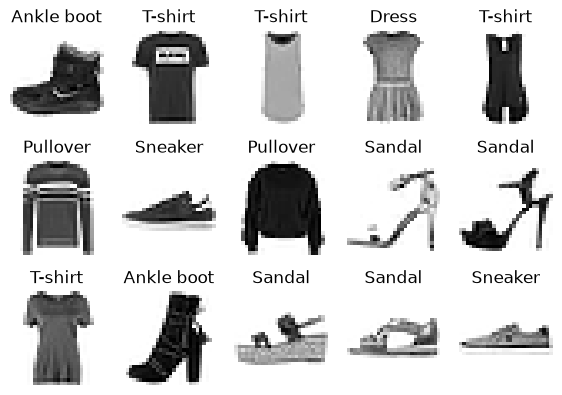

In [97]:
def show_imgs(n_rows, n_cols, train_ds, class_names):
    # 确保打印的图片小于总样本数
    assert n_rows * n_cols < len(train_ds)
    # 宽 1.4 ； 高  1.6
    plt.figure(figsize=(n_cols * 1.4, n_rows * 1.6))
    for row in range(n_rows):
        for col in range(n_cols):
            # 计算索引，从0开始
            index = n_cols * row + col
            """
            在一张画布上划分多个子图网格，选中其中某一个格子，后续绘图就画在这个格子里
            n_rows：整个画布分成多少行
            n_cols：整个画布分成多少列
            第三个参数：子图编号，从1开始，不是0！这就是为什么写index+1：你的循环一般从0开始计数，+1适配matplotlib从1开始编号
            """
            plt.subplot(n_rows, n_cols, index + 1)
            # 解包，图像数据、标签数据
            img_arr, label = train_ds[index]
            # 通道换到最后一维
            img_arr = np.transpose(img_arr, (1, 2, 0))
            """
            cmap = Color Map：
                作用：把图片里的数字像素值映射成对应的颜色
                比如你写的cmap='binary'；数值小 -> 黑色；数值大 -> 白色，正好适配FashionMNIST灰度图
                常用取值：
                    binary：黑白，0黑1白（FashionMNIST首选）
                    gray：灰度图（和binary相反，0黑，越大越白）
                    viridis：matplotlib默认的彩色渐变色
                小知识点（后缀加_r代表反转reverse）：
                    binary_r：数值小是白色，数值大是黑色
            interpolation：插值方式
                nearest：最近邻插值；放大图片的时候，不要平滑模糊，直接取最近像素的值；就近复制旁边像素，方快感很强，不会模糊，能看清原始像素网格（非常适合FashionMNSIT这种28*28的小图）
                bilinear：平滑插值，放大后图片柔和，适合自然照片
            """
            plt.imshow(img_arr, cmap='binary', interpolation='nearest')
            # 关闭坐标轴（x轴、y轴、刻度、边框全部隐藏）
            plt.axis('off')
            # 给子图添加标题
            plt.title(class_names[label])
    plt.show()
    
# 已知的图片类别labels在这个路径https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']    # 0-9分别代表类别
# 只是打印了前15个样本
show_imgs(3, 5, train_ds, class_names)

In [98]:
# 从数据集到dataloader
"""
DataLoader：数据集迭代器，作用是train_ds(Dataset数据集对象)打包成一批一批（batch）的数据，方便训练循环读取
    train_ds：前面定义的数据集对象（datasets.FashionMNIST），存放全部训练样本
    batch_size=32:每一批次取出32张图片+对应32个标签；依次喂给模型32个样本做一次梯度更新
    shuffle=True：每一轮epoch（遍历完整数据集一次）打乱样本顺序；
        训练集一般打开shuffle=True，防止模型学到样本样本的顺序偏见；
        测试集/验证集DataLoader一定要设shuffle=False，不要打乱
    返回的train_loader
        遍历它的时候，每次取出：(imgs, labels)
        imgs：[32, 1, 28, 28]，batch=32，单通道，28*28
        labels：[32]，32个图片对应的类别标签
"""
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)       # batch_size分批，shuffle洗牌
val_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。



# 定义模型

In [99]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        # 继承父类初始化方法，子类有父类的属性
        super().__init__()
        # 自定义属性，实例化两个对象
        self.flatten = nn.Flatten()
        """
        nn.Sequential是PyTorch中用于快速搭建顺序（串行）神经网络的容器，它按照模块传入顺序，自动将前一个层的输出作为下一个层的输入。使用nn.Sequential可以极大地简化代码，避免手动在forward函数中逐层调用
        """
        self.linear_relu_stack = nn.Sequential(
            # in_features=784, out_features=300, 784是输入特征数，300是输出特征数
            nn.Linear(784, 300),
            nn.ReLU(),                  # 激活函数
            # 隐藏层神经元数100
            nn.Linear(300, 100),
            nn.ReLU(),                  # 激活函数
            # 输出层神经元数10
            nn.Linear(100, 10),
        )
        
    def forward(self, x):
        # x.shape [batch size, 1, 28, 28
        x = self.flatten(x)
        # 展平后 x.shape [batch size, 784]
        logits = self.linear_relu_stack(x)
        # logits.shape [batch size, 10]
        return logits       # 没有经过softmax，称为logits
    
# 实例化一个对象
model = NeuralNetwork()

In [100]:
model                               # 看看网络结构
"""
(flatten): Flatten(start_dim=1, end_dim=-1)
    作用：将多维输入特征展平成一维向量
    细节：在图像任务中，输入通常是（batch_size, channels, height, width），例如单通道的28*28图像（加上通道数后形状为（batch_size, 1, 28, 28））
    操作：start_dim=1表示保留第0维（即Batch批次大小），将从第1维开始的所有维度展平。展平后的特征维度维1*28*28=784
(linear_relu_stack):Sequential(...):
    这是一个包含5个子层的顺序容器nn.Sequential，数据会依次流经这5个层：
        （0）：Linear(in_features=784, out_features=300, bias=True)
            第一层全连接层（输入层 -> 隐藏层1）：接收展平后的784维向量，将其线性变换升维/降维到300维的隐藏特征。包含偏置项 bias=True
        （1）：ReLU()
            激活函数：引入非线性能力，计算公式为f(x)=max(0, x)。使网络能够学习复杂的非线性关系
        （2）：Linear(in_features=300, out_features=100, bias=True)
            第二层全连接层（隐藏层1 -> 隐藏层2）：将300维特征压缩/提取到100维
        （3）：ReLU()
            激活函数：再次引入非线性
        （4）：Linear(in_features=100, out_features=10, bias=Ture)
            第三层全连接层（输出层）：将100维特征映射到最终10个节点。这通常对应10分类任务（例如识别数字0-9）
"""

'\n(flatten): Flatten(start_dim=1, end_dim=-1)\n    作用：将多维输入特征展平成一维向量\n    细节：在图像任务中，输入通常是（batch_size, channels, height, width），例如单通道的28*28图像（加上通道数后形状为（batch_size, 1, 28, 28））\n    操作：start_dim=1表示保留第0维（即Batch批次大小），将从第1维开始的所有维度展平。展平后的特征维度维1*28*28=784\n(linear_relu_stack):Sequential(...):\n    这是一个包含5个子层的顺序容器nn.Sequential，数据会依次流经这5个层：\n        （0）：Linear(in_features=784, out_features=300, bias=True)\n            第一层全连接层（输入层 -> 隐藏层1）：接收展平后的784维向量，将其线性变换升维/降维到300维的隐藏特征。包含偏置项 bias=True\n        （1）：ReLU()\n            激活函数：引入非线性能力，计算公式为f(x)=max(0, x)。使网络能够学习复杂的非线性关系\n        （2）：Linear(in_features=300, out_features=100, bias=True)\n            第二层全连接层（隐藏层1 -> 隐藏层2）：将300维特征压缩/提取到100维\n        （3）：ReLU()\n            激活函数：再次引入非线性\n        （4）：Linear(in_features=100, out_features=10, bias=Ture)\n            第三层全连接层（输出层）：将100维特征映射到最终10个节点。这通常对应10分类任务（例如识别数字0-9）\n'

In [101]:
784*300 + 300 + 300*100 + 100 + 100*10 + 10

266610

In [102]:
"""
named_parameters()是nn.Module的方法，遍历模型中所有可训练参数（requires_grad=True的权重/偏置），同时返回 [参数名字符串，参数张量param]
    返回 (name, param)元组，带名字，调试非常方便
model.parameters()：
    只返回param张量，没有名字
"""
for name, param in model.named_parameters():
    # print(name, param.shape)
    print(f'{name:<30} {param.shape}')
"""
下面输出的结果分别是：
    784 -> 300时所使用的权重数量：300*784  偏置值：300
    300 -> 100时所使用的权重数量：100*300  偏置值：100
    100 -> 10时所使用的权重数量： 10*100   偏置值：10
"""

linear_relu_stack.0.weight     torch.Size([300, 784])
linear_relu_stack.0.bias       torch.Size([300])
linear_relu_stack.2.weight     torch.Size([100, 300])
linear_relu_stack.2.bias       torch.Size([100])
linear_relu_stack.4.weight     torch.Size([10, 100])
linear_relu_stack.4.bias       torch.Size([10])


'\n下面输出的结果分别是：\n    784 -> 300时所使用的权重数量：300*784  偏置值：300\n    300 -> 100时所使用的权重数量：100*300  偏置值：100\n    100 -> 10时所使用的权重数量： 10*100   偏置值：10\n'

In [103]:
"""
在PyTorch中，requires_grad=True是张量（Tensor）的一个关键属性标志。它的作用是告知PyTorch的自动求导引擎（Autograd）：在计算图中追踪该张量的所有操作，以便在调用.backward()时自动计算它的梯度
    1.构建计算图（Computation Graph）：
        当一个张量的requires_grad被设置为True时，PyTorch会开始跟踪对它进行的所有数学运算，并在后台动态构建一张有向无环图（DAG），记录每一步的运算操作（grad_fn）
    2.保留梯度供优化器更新：
        在反向传播（loss.backward()）时，PyTorch会利用链式法则从Output逆向计算每个requires_grad=True的张量偏导数，并将结果存储在该张量的.grad属性中，供优化器（如SGD、Adam）更新权重
模型参数（Model Parameters）：
    在深度学习中，神经网络所有权重（weight）和偏置（bias）在初始化时，requires_grad默认都自动为True
输入数据（Inputs）与中间变量：
    你自己创建的基础张量（如x = torch.tensor([1.0, 2.0]))，requires_grad默认为False。因为通常我们只需要更新模型权重，不需要计算输入数据的梯度
"""
list(model.parameters())

[Parameter containing:
 tensor([[ 0.0208,  0.0356, -0.0228,  ...,  0.0292,  0.0253, -0.0025],
         [-0.0103,  0.0039,  0.0312,  ..., -0.0124,  0.0330, -0.0173],
         [-0.0212, -0.0200, -0.0146,  ..., -0.0102, -0.0170,  0.0258],
         ...,
         [-0.0311,  0.0066,  0.0083,  ...,  0.0148, -0.0349, -0.0300],
         [-0.0156, -0.0085, -0.0086,  ...,  0.0275, -0.0255, -0.0130],
         [-0.0130, -0.0274,  0.0085,  ...,  0.0221, -0.0092,  0.0134]],
        requires_grad=True),
 Parameter containing:
 tensor([-1.2960e-02,  6.4178e-04, -6.8831e-04,  2.8869e-02, -2.3431e-03,
         -3.3146e-02,  2.0376e-02,  2.9112e-02, -7.2888e-06, -1.3355e-02,
          1.6152e-02,  1.7006e-02, -1.7126e-02,  4.8452e-03, -4.1163e-03,
          1.1571e-02, -6.9833e-03,  1.2599e-02, -2.6246e-02,  1.4413e-02,
          5.1543e-03, -1.7795e-02, -3.1843e-02, -1.2579e-04, -3.4285e-02,
         -1.0299e-02,  2.0578e-02, -1.9207e-02, -1.9969e-02,  8.3404e-03,
         -2.0695e-02, -2.0138e-02, -3.26

In [104]:
"""
    在PyTorch中，model.state_dict()是一个非常重要的Python字典（Dictionary）对象，它将神经网络的每一层与其对应的可学习参数（权重Weights和偏置Biases）及持久缓冲区（Buffers）映射起来
包含的内容：
    可学习参数（parameters）：如全连接层的权重和偏置（weight、bias），即所有requires_grad=True的张量
    缓冲状态（Buffers）：如Batch Normalization层中的运行均值（running_mean）和运行方差（running_var）。这些虽无需求导更新，但属于模型状态的一部分
简单模型：
    import torch
    import torch.nn as nn
    
    class SimpleNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(3, 2)
            self.bn = nn.BatchNorm1d(2)
    
    model = SimpleNet()
    
    # 查看 state_dict 的键 (Keys)
    for key in model.state_dict():
        print(key)
输出结果：
    fc1.weight
    fc1.bias
    bn.weight
    bn.bias
    bn.running_mean
    bn.running_var
    bn.num_batches_tracked
保存模型权重：
    # 将模型的权重字典保存到磁盘文件（通常后缀为 .pt 或 .pth）
    torch.save(model.state_dict(), 'model_weights.pth')
加载模型权重（加载时，必须先实例化相同的模型结构，然后再使用load_state_dict()将权重灌入模型中）：
    # 1. 实例化模型结构
    model = SimpleNet()
    
    # 2. 从磁盘读取 state_dict 字典
    state_dict = torch.load('model_weights.pth')
    
    # 3. 将权重加载到模型中
    model.load_state_dict(state_dict)
常见应用场景：
    1 迁移学习/微调（Transfer Learning/ Fine-tuning）:
        只加载部分预训练权重。可以通过修改字典键值对，过滤掉不需要的输出层权重
        pretrained_dict = torch.load('pretrained.pth')
        model_dict = model.state_dict()
        
        # 过滤掉形状不匹配或不需要的层（如最后一层分类头）
        filtered_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
        
        # 更新当前模型的 state_dict 并加载
        model_dict.update(filtered_dict)
        model.load_state_dict(model_dict)
    2 保存检查点（Checkpointing）：
        在断点续训时，除了保存模型的state_dict()，通常还会把优化器（Optimizer）的state_dict()一起打包保存
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
        }
        torch.save(checkpoint, 'checkpoint.pth')
"""
# model.state_dict()    这种方法用于保存模型参数，能看见参数属于模型哪一部分

"\n    在PyTorch中，model.state_dict()是一个非常重要的Python字典（Dictionary）对象，它将神经网络的每一层与其对应的可学习参数（权重Weights和偏置Biases）及持久缓冲区（Buffers）映射起来\n包含的内容：\n    可学习参数（parameters）：如全连接层的权重和偏置（weight、bias），即所有requires_grad=True的张量\n    缓冲状态（Buffers）：如Batch Normalization层中的运行均值（running_mean）和运行方差（running_var）。这些虽无需求导更新，但属于模型状态的一部分\n简单模型：\n    import torch\n    import torch.nn as nn\n\n    class SimpleNet(nn.Module):\n        def __init__(self):\n            super().__init__()\n            self.fc1 = nn.Linear(3, 2)\n            self.bn = nn.BatchNorm1d(2)\n\n    model = SimpleNet()\n\n    # 查看 state_dict 的键 (Keys)\n    for key in model.state_dict():\n        print(key)\n输出结果：\n    fc1.weight\n    fc1.bias\n    bn.weight\n    bn.bias\n    bn.running_mean\n    bn.running_var\n    bn.num_batches_tracked\n保存模型权重：\n    # 将模型的权重字典保存到磁盘文件（通常后缀为 .pt 或 .pth）\n    torch.save(model.state_dict(), 'model_weights.pth')\n加载模型权重（加载时，必须先实例化相同的模型结构，然后再使用load_state_dict()将权重灌入模型中）：\n    # 1. 实例化模型结构\n    model = SimpleNet()\n\n 

# 训练
pytorch的训练需要自行实现，包括
1. 定义损失函数
2. 定义优化器
3. 定义训练步
4. 训练

In [105]:
# 1. 定义损失函数，采用交叉熵损失
loss_fct = nn.CrossEntropyLoss()

# 2. 定义优化器，采用SGD
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [108]:
from sklearn.metrics import accuracy_score

@torch.no_grad()        # 装饰器，禁止反向传播，节省内存
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    pred_list = []
    label_list = []
    for datas, labels in dataloader:
        datas = datas.to(device)
        labels = labels.to(device)
        
        logits = model(datas)
        loss = loss_fct(logits, labels)
        loss_list.append(loss.item())
        
        preds = logits.argmax(axis=-1)
        pred_list.extend(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())
    
    acc = accuracy_score(label_list, pred_list)
    return np.mean(loss_list), acc

In [109]:
print(evaluating(model, val_loader, loss_fct))

(np.float64(2.300824821185761), 0.0987)
